#Online Retail Customer Segmentation using RFM Analysis

Google Collab Link : [https://colab.research.google.com/drive/1k6woNvzdIxw7cVuIv6-KqPZZ7AOEBeXj?usp=sharing]

###Data Ingestion & Initial Inspection

In [1]:
import pandas as pd
import numpy as np
import datetime as dt
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
sns.set_theme(style="whitegrid")

In [9]:
df = pd.read_csv("/content/Online Retail Data Set.csv", encoding="ISO-8859-1")

In [11]:
f"Initial dataset shape: {df.shape}"

'Initial dataset shape: (247211, 8)'

In [13]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6.0,01-12-2010 08:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6.0,01-12-2010 08:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8.0,01-12-2010 08:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6.0,01-12-2010 08:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6.0,01-12-2010 08:26,3.39,17850.0,United Kingdom


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 247211 entries, 0 to 247210
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    247211 non-null  object 
 1   StockCode    247211 non-null  object 
 2   Description  246279 non-null  object 
 3   Quantity     247210 non-null  float64
 4   InvoiceDate  247210 non-null  object 
 5   UnitPrice    247210 non-null  float64
 6   CustomerID   178045 non-null  float64
 7   Country      247210 non-null  object 
dtypes: float64(3), object(5)
memory usage: 15.1+ MB


###Data Cleaning & Preprocessing

In [15]:
# 1. Drop rows with missing CustomerID (guest checkouts cannot be tracked for RFM)
df.dropna(subset=['CustomerID'], inplace=True)

In [16]:
# 2. Remove cancelled transactions (Invoice numbers starting with 'C')
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

In [17]:
# 3. Filter out rows with negative or zero Quantity / UnitPrice (returns or adjustments)
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]

In [18]:
# 4. Convert InvoiceDate to proper datetime format
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], format='%d-%m-%Y %H:%M')

In [19]:
# 5. Create a TotalPrice feature for monetary analysis
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

In [20]:
f"Cleaned dataset shape: {df.shape}"

'Cleaned dataset shape: (173746, 9)'

###RFM Feature Engineering

In [21]:
# Set a reference snapshot date (1 day after the latest transaction)
snapshot_date = df['InvoiceDate'].max() + dt.timedelta(days=1)

In [22]:
# Group by CustomerID
rfm_df = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days, # Recency: Days since last purchase
    'InvoiceNo': 'nunique',                                  # Frequency: Total unique transactions
    'TotalPrice': 'sum'                                      # Monetary: Total spend
})

In [23]:
# Rename columns for clarity
rfm_df.rename(columns={
    'InvoiceDate': 'Recency',
    'InvoiceNo': 'Frequency',
    'TotalPrice': 'Monetary'
}, inplace=True)

In [24]:
rfm_df.describe()

,Recency,Frequency,Monetary
count,2968.000000,2968.000000,2968.000000
mean,73.951482,2.983827,1350.764771
std,60.517455,4.618993,4896.745192
min,1.000000,1.000000,2.900000
25%,24.000000,1.000000,250.030000
50%,54.000000,2.000000,496.755000
75%,111.000000,3.000000,1134.375000
max,215.000000,106.000000,136002.110000


###Customer Behavioral Scoring (RFM Quantiles)

In [25]:
# Assign ranks (Recency: lower is better; Frequency & Monetary: higher is better)
r_labels = range(4, 0, -1)
f_labels = range(1, 5)
m_labels = range(1, 5)

rfm_df['R_Score'] = pd.qcut(rfm_df['Recency'], 4, labels=r_labels)
rfm_df['F_Score'] = pd.qcut(rfm_df['Frequency'].rank(method='first'), 4, labels=f_labels)
rfm_df['M_Score'] = pd.qcut(rfm_df['Monetary'], 4, labels=m_labels)

In [26]:
# Combine scores into a unified string identifier
rfm_df['RFM_Score'] = rfm_df['R_Score'].astype(str) + rfm_df['F_Score'].astype(str) + rfm_df['M_Score'].astype(str)

In [27]:
# Calculate total RFM Score sum
rfm_df['RFM_Total_Score'] = rfm_df['R_Score'].astype(int) + rfm_df['F_Score'].astype(int) + rfm_df['M_Score'].astype(int)

In [29]:
rfm_df.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,RFM_Total_Score
CustomerID,,,,,,,,
12346.0,167,1,77183.60,1,1,4,114,6
12347.0,24,4,2205.95,4,4,4,444,12
12348.0,90,3,1487.24,2,3,4,234,9
12350.0,151,1,334.40,1,1,2,112,4
12352.0,103,5,1561.81,2,4,4,244,10


In [36]:
# Customer Segmentation Labels

def rfm_segment(row):
    """
    Map RFM scores to meaningful business segments
    """
    if row['RFM_Total_Score'] >= 10:
        return 'Champions'
    elif row['RFM_Total_Score'] >= 8:
        return 'Loyal Customers'
    elif row['RFM_Total_Score'] >= 6:
        return 'Potential Loyalists'
    elif row['R_Score'] >= 3 and row['F_Score'] <= 2:
        return 'New Customers'
    elif row['R_Score'] <= 2 and row['F_Score'] >= 3:
        return 'At Risk'
    elif row['R_Score'] <= 2 and row['F_Score'] <= 2:
        return 'Hibernating'
    else:
        return 'Need Attention'

rfm_df['Segment'] = rfm_df.apply(rfm_segment, axis=1)

# Check segment distribution
print("Customer Segment Distribution:")
rfm_df['Segment'].value_counts()

Customer Segment Distribution:


,count
Segment,
Champions,847
Hibernating,840
Potential Loyalists,640
Loyal Customers,589
New Customers,37
At Risk,15


In [37]:
print("\nPercentage:")
(rfm_df['Segment'].value_counts(normalize=True) * 100).round(2)


Percentage:


,proportion
Segment,
Champions,28.54
Hibernating,28.30
Potential Loyalists,21.56
Loyal Customers,19.85
New Customers,1.25
At Risk,0.51


In [39]:
# 2. Detailed Segment Analysis
segment_summary = rfm_df.groupby('Segment').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': ['mean', 'sum', 'count']
}).round(1)

# Flatten column names
segment_summary.columns = ['Avg_Recency', 'Avg_Frequency', 'Avg_Monetary', 'Total_Revenue', 'Customer_Count']
segment_summary = segment_summary.sort_values('Total_Revenue', ascending=False)

# Add percentage of total revenue
segment_summary['Revenue_%'] = (segment_summary['Total_Revenue'] / segment_summary['Total_Revenue'].sum() * 100).round(1)
segment_summary['Customer_%'] = (segment_summary['Customer_Count'] / segment_summary['Customer_Count'].sum() * 100).round(1)

print("Segment Performance Summary ")
display(segment_summary)

Segment Performance Summary 


,Avg_Recency,Avg_Frequency,Avg_Monetary,Total_Revenue,Customer_Count,Revenue_%,Customer_%
Segment,,,,,,,
Champions,24.1,6.6,3372.3,2856351.2,847,71.2,28.5
Loyal Customers,53.0,2.4,956.4,563339.3,589,14.1,19.8
Potential Loyalists,72.1,1.4,585.5,374705.6,640,9.3,21.6
Hibernating,140.5,1.0,246.0,206621.9,840,5.2,28.3
New Customers,39.3,1.0,147.1,5442.1,37,0.1,1.2
At Risk,148.9,2.1,174.0,2609.7,15,0.1,0.5


###Exploratory Data Analysis & Visualizations

####A. Revenue Contribution by Top Country

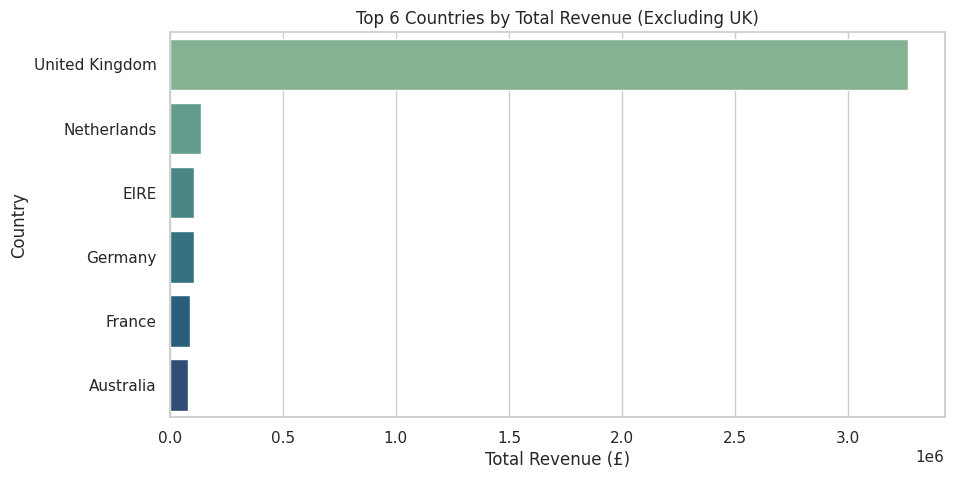

In [31]:
plt.figure(figsize=(10, 5))
country_sales = df.groupby('Country')['TotalPrice'].sum().sort_values(ascending=False).head(6)
sns.barplot(x=country_sales.values, y=country_sales.index, hue=country_sales.index, palette='crest', legend=False)
plt.title('Top 6 Countries by Total Revenue (Excluding UK)')
plt.xlabel('Total Revenue (£)')
plt.ylabel('Country')
plt.show()

####B. Customer Segment Scatter Plot (Recency vs. Monetary)

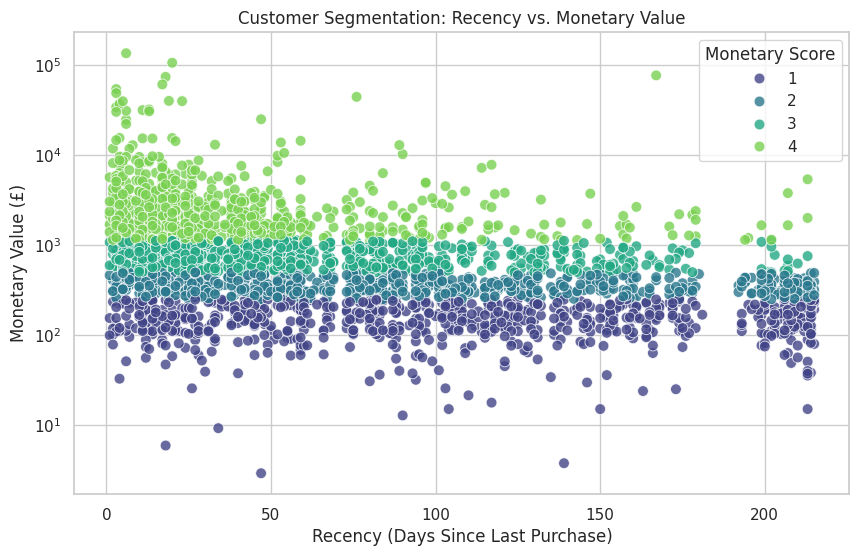

In [32]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=rfm_df,
    x='Recency',
    y='Monetary',
    hue='M_Score',
    palette='viridis',
    alpha=0.8,
    s=60
)
plt.title('Customer Segmentation: Recency vs. Monetary Value')
plt.xlabel('Recency (Days Since Last Purchase)')
plt.ylabel('Monetary Value (£)')
plt.yscale('log') # Using log scale due to high spending outliers
plt.legend(title='Monetary Score')
plt.show()

####C. Segment Distribution

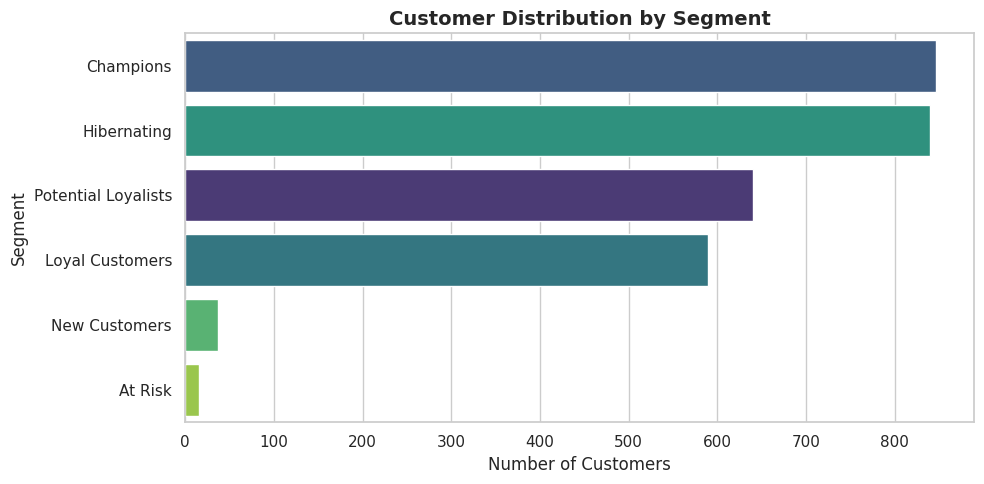

In [43]:
plt.figure(figsize=(10, 5))
order = rfm_df['Segment'].value_counts().index
sns.countplot(data=rfm_df, y='Segment', order=order, palette='viridis', hue='Segment', legend=False)
plt.title('Customer Distribution by Segment', fontsize=14, fontweight='bold')
plt.xlabel('Number of Customers')
plt.ylabel('Segment')
plt.tight_layout()
plt.show()

####D. Revenue Contribution by Segment

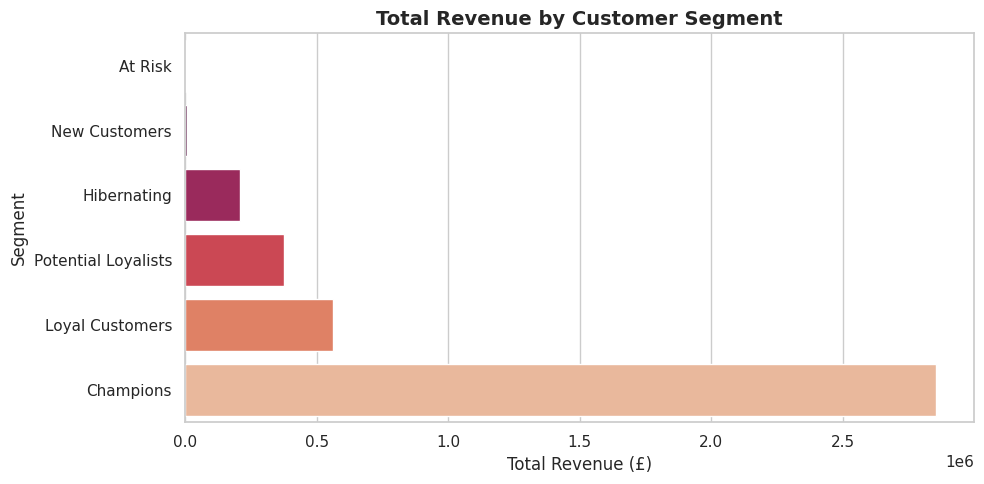

In [45]:
plt.figure(figsize=(10, 5))
rev_order = segment_summary.sort_values('Total_Revenue', ascending=True).index
sns.barplot(x=segment_summary.loc[rev_order, 'Total_Revenue'],
            y=rev_order, palette='rocket', hue=rev_order, legend=False)
plt.title('Total Revenue by Customer Segment', fontsize=14, fontweight='bold')
plt.xlabel('Total Revenue (£)')
plt.ylabel('Segment')
plt.tight_layout()
plt.show()

#### E. Average Monetary Value by Segment

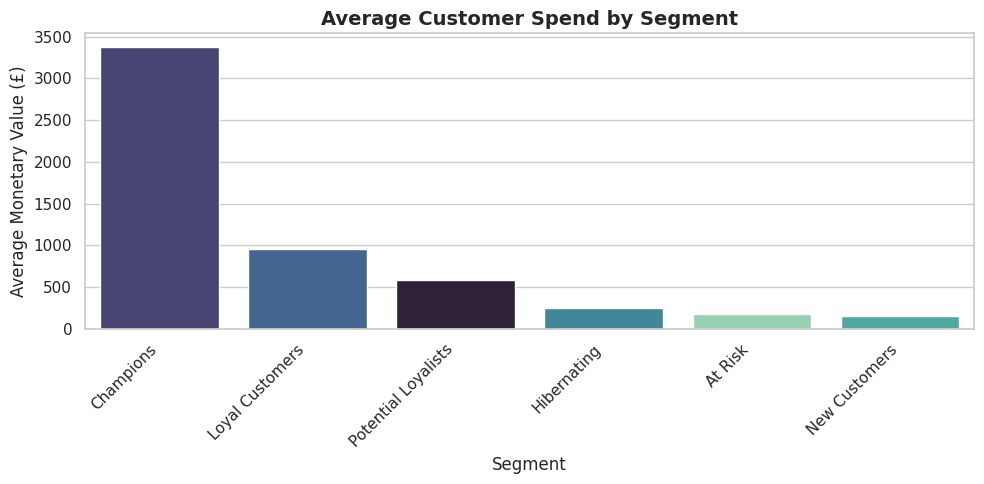

In [48]:
plt.figure(figsize=(10, 5))
sns.barplot(data=rfm_df, x='Segment', y='Monetary',
            order=rfm_df.groupby('Segment')['Monetary'].mean().sort_values(ascending=False).index,
            palette='mako', estimator='mean', errorbar=None,hue='Segment', legend=False)
plt.title('Average Customer Spend by Segment', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Average Monetary Value (£)')
plt.tight_layout()
plt.show()

#### F. Recency vs Frequency colored by Segment

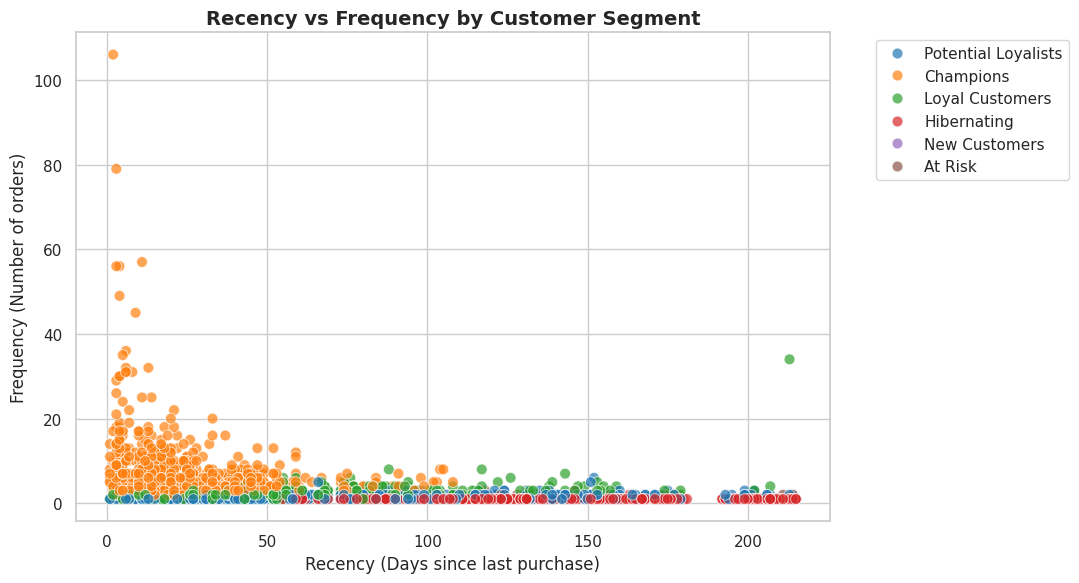

In [49]:
plt.figure(figsize=(11, 6))
sns.scatterplot(data=rfm_df, x='Recency', y='Frequency',
                hue='Segment', palette='tab10', alpha=0.7, s=60)
plt.title('Recency vs Frequency by Customer Segment', fontsize=14, fontweight='bold')
plt.xlabel('Recency (Days since last purchase)')
plt.ylabel('Frequency (Number of orders)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

---
### 📊 Key Insights from the Analysis

1. **Revenue Concentration (Pareto Principle)**  
   A small group of customers (**Champions** and **Loyal Customers**) generate a disproportionately large share of total revenue, while making up a smaller percentage of the customer base. This is a classic 80/20 pattern commonly seen in retail.

2. **High-Value Customers Drive the Business**  
   Champions and Loyal Customers have the highest average Monetary value and purchase frequency. Protecting and nurturing these segments should be the top business priority.

3. **Significant Reactivation Opportunity**  
   A large portion of customers fall into the **Hibernating** and **At Risk** segments. These customers have purchased in the past but have not returned recently. Targeted win-back campaigns can unlock substantial dormant revenue.

4. **New Customers Need Nurturing**  
   New Customers show recent activity but low frequency. Converting them into repeat buyers through welcome series and first-repeat incentives can improve long-term customer lifetime value.

5. **Geographic Concentration**  
   The United Kingdom dominates total revenue. International markets (Netherlands, EIRE, Germany, France, etc.) contribute meaningfully but are secondary.

---

### 🎯 Recommended Business Actions

| Segment               | Priority | Recommended Strategy                              | Suggested Actions                                      |
|-----------------------|----------|---------------------------------------------------|--------------------------------------------------------|
| **Champions**         | Highest  | Reward & Retain                                   | Exclusive offers, loyalty rewards, early access, VIP treatment |
| **Loyal Customers**   | High     | Upsell & Cross-sell                               | Personalized product recommendations, bundle offers    |
| **Potential Loyalists**| Medium  | Increase Engagement                                | Targeted email campaigns, limited-time discounts       |
| **New Customers**     | Medium   | Convert to Repeat Buyers                          | Welcome series + first-repeat purchase discount        |
| **At Risk**           | High     | Win-back                                          | Personalized reactivation offers, “We miss you” campaigns |
| **Hibernating**       | Medium   | Reactivate or Suppress                            | Last-chance offers or reduce marketing spend           |
| **Need Attention**    | Low      | Investigate & Nurture                             | Surveys + light personalized outreach                  |

---

### 💡 Strategic Takeaway

Focusing on **retention and reactivation** of existing high-value and at-risk customers will deliver higher ROI in the short-to-medium term compared to pure acquisition efforts. Segment-specific marketing is essential to maximize customer lifetime value.